In [105]:
#### Importando modulos
import pandas as pd
import numpy as np
import scipy
from scipy import stats
import matplotlib.pyplot as plt


In [106]:
##### Funcion para integrar posiciones
def posiciones(df_r: pd.DataFrame, empresas: list[str], tipo:str):
    df_posiciones = pd.DataFrame()
    #### Extracciones individuales
    if tipo=='sliding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'SlidingFinalPreds/pred_sliding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='expanding':
        for i in range(22):
            tmp = scipy.io.loadmat(f'ExpandingFinalPreds/pred_expanding_{i}.mat')
            df_tmp = pd.DataFrame(tmp['Ypred_final'])
            df_posiciones = pd.concat([df_posiciones, df_tmp], axis=0, ignore_index=True)
        del tmp
        df_posiciones.columns = [f'Posicion.{nom}' for nom in empresas]
    elif tipo=='todo':
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [1] * df_r.shape[0]
    elif tipo=='rand':
        import random
        random.seed(42)
        for nom in empresas:
            df_posiciones[f'Posicion.{nom}'] = [random.randint(0,1) for _ in range(df_r.shape[0])]


    #### Asegurando que df_posiciones tenga mismo numero de datos
    df_posiciones = df_posiciones.iloc[:df_r.shape[0]]

    #### Camiando indices
    df_posiciones.index = df_r.index
    
    #### Sumando cantidad de posiciones
    suma = df_posiciones.sum(axis=1)

    #### Asignando posiciones equitativamente
    df_posiciones_finales = df_posiciones.div(suma, axis=0)

    #### Integrando posiciones con rendimientos
    df_integrado = pd.concat([df_r,df_posiciones_finales], axis=1, ignore_index=False)

    return df_integrado


In [107]:
##### Calculando formula para la rentabilidad del portafolio

def calc_rentabilidad(df:pd.Dataframe, empresas: list[str], tgt: int = 0.1, costo : int = 0.00001) -> pd.Dataframe:
    """
    Formula para calcular la rentabilidad de un portafolio 

    Params:
    df: el dataframe que contiene los rendimientos, EWMSD, y posiciones del portafolio
    tgt: la voltatilidad deseada para escalar la volatilidad proporcionalmente
    costo: costo de cambiar las posiciones de las acciones en un portafolio
  l
    Return:
    df_rentabilidad: el df que contiene la rentabilidad del portafolio por las fechas marcadas
    """
    #### Calculando rentabilidad equitativa por cada accion/empresa
    df_rentabilidad = pd.DataFrame()
    for name in empresas:
        df_rentabilidad[f'Rentabilidad.{name}'] = df[name] * (tgt/df[f'EWMSD.{name}'].shift(1))  * df[f'Posicion.{name}'].shift(1) - \
        costo*abs(((tgt/df[f'EWMSD.{name}'].shift(1))*df[f'Posicion.{name}'].shift(1)) - ((tgt/df[f'EWMSD.{name}'].shift(2))*df[f'Posicion.{name}'].shift(2)))
        # df_rentabilidad[f'Rentabilidad.{name}'] = df[name] * df[f'Posicion.{name}']


    #### Elimando primera dos fila por el "shift(2)"
    df_rentabilidad_diaria = df_rentabilidad.iloc[2:]

    return df_rentabilidad_diaria



In [108]:
#### Formula para cargar y limpiar datos
def cargar(nom:str):
    ### Cargando datos
    df = pd.read_csv(nom, index_col='Date')

    ### Nombre de las 32 empresas
    empresas = df.columns.to_list()

    ### Calculando EWMSD
    for name in empresas:
        df[f'EWMSD.{name}'] = df[name].ewm(span=30, adjust=False).std()

    ### Eliminando datos
    df = df.iloc[:-62]
    df = df.iloc[345:]

    #### Calculando posiciones
    df_posiciones= posiciones(df, empresas, 'todo')    

    #### Calculado rentabilidades diarias de todas acciones
    df_rentabilidad_diaria = calc_rentabilidad(df_posiciones, empresas)
    
    return df_rentabilidad_diaria
    

In [109]:
#### Formula para cargar y limpiar datos
def cargar2(nom:str):
    ### Cargando datos
    df = pd.read_csv(nom, index_col='Date')

    ### Nombre de las 32 empresas
    empresas = df.columns.to_list()

    ### Calculando EWMSD
    for name in empresas:
        df[f'EWMSD.{name}'] = df[name].ewm(span=30, adjust=False).std()

    ### Eliminando datos
    df = df.iloc[:-62]
    df = df.iloc[345:]

    #### Calculando posiciones
    df_posiciones= posiciones(df, empresas, 'sliding')    

    #### Calculado rentabilidades diarias de todas acciones
    df_rentabilidad_diaria = calc_rentabilidad(df_posiciones, empresas)
    
    return df_rentabilidad_diaria

In [110]:
#### Funcion para hacer test 1 y test 2 (retest)
def test(df:pd.DataFrame, fecha_comienzo: str, dias: int, offset: int):
    ### Extrayendo df
    df_deseado = df.loc[fecha_comienzo:]

    ### Selecionado fechas iniciales
        # Va a ver un dia de separacion para integrar la preddicion del LSTM
    df_inicial = df_deseado.iloc[offset:dias+offset]    #Valores Inicial
    df_final = df_deseado.iloc[offset+1:dias+offset+1]    #Valores Finales
    

    print(f'Fechas iniciales: {df_inicial.iloc[0].name}, {df_inicial.iloc[-1].name}\t Fechas finales: {df_final.iloc[0].name}, {df_final.iloc[-1].name}')

    ### Rendimientos
    ## Valores esperados
    df_inicial_rend_esperados = df_inicial.mean(axis=0)
    df_final_rend_esperados = df_final.mean(axis=0)

    ## Indice rendimiento
    # df_indice_rend = (df_final_rend_esperados - df_inicial_rend_esperados)/(df_inicial_rend_esperados + 1e-8)
    df_indice_rend = (df_final_rend_esperados - df_inicial_rend_esperados)/(df_inicial_rend_esperados.abs() + 1e-8)


    ### Desviacion estandard 
    ## Valores
    df_inicial_std = df_inicial.std(axis=0, ddof=0)
    df_final_std = df_final.std(axis=0, ddof=0)

    ## Indice
    # df_indice_std = (df_final_std - df_inicial_std)/(df_inicial_std + 1e-8)
    df_indice_std = (df_final_std - df_inicial_std)/(df_inicial_std.abs() + 1e-8)

    # return df_indice_rend.to_list(), df_indice_std.to_list()                        # Instrumento original
    return df_inicial_rend_esperados.to_list(), df_inicial_std.to_list()            # Instrumento modificado

In [111]:
#### Funcion para ejecutar las pruebas
def pruebas(df: pd.DataFrame, test1_fecha: str, dias: int, diff: int):
    '''
    df: dataframe
    test1_fecha: fecha de comienzo
    dias: dias dentro del periodo de std y expected returns
    diff: diferencia entre test 1 y test 2 (retest)
    '''

    ### Creando indices
    indice_rend_test1, indice_std_test1 = test(df, test1_fecha, dias, 0)
    indice_rend_test2, indice_std_test2 = test(df, test1_fecha, dias, diff)


    ### Probando normalidad: 32 > 30 => usar Kolgomorov smirnov
    norm_rend_test1_estad, norm_rend_test1_pvalor = stats.kstest(indice_rend_test1, 'norm')
    norm_rend_test2_estad, norm_rend_test2_pvalor = stats.kstest(indice_rend_test2, 'norm')
    norm_std_test1_estad, norm_std_test1_pvalor = stats.kstest(indice_std_test1, 'norm')
    norm_std_test2_estad, norm_std_test2_pvalor = stats.kstest(indice_std_test2, 'norm')

    ### Correlacion Spearman
    ALT = 'two-sided'      #'two-sided', 'less', 'greater'; solo cambia pvalor
    spear_rend_estad, spear_rend_pvalor = stats.spearmanr(indice_rend_test1, indice_rend_test2, alternative=ALT)
    spear_std_estad, spear_std_pvalor = stats.spearmanr(indice_std_test1, indice_std_test2, alternative=ALT)

    ### Correlacion Pearson
    pear_rend_estad, pear_rend_pvalor = stats.pearsonr(indice_rend_test1, indice_rend_test2)
    pear_std_estad, pear_std_pvalor = stats.pearsonr(indice_std_test1, indice_std_test2)

    ### Tabla visual
    ## Creado tabla
    data = np.array([
        [norm_rend_test1_estad, norm_rend_test1_pvalor],
        [norm_rend_test2_estad, norm_rend_test2_pvalor],
        [norm_std_test1_estad, norm_std_test1_pvalor],
        [norm_std_test2_estad, norm_std_test2_pvalor],
        [spear_rend_estad, spear_rend_pvalor],
        [spear_std_estad, spear_std_pvalor],
        [pear_rend_estad, pear_rend_pvalor],
        [pear_std_estad, pear_std_pvalor]
    ])

    ## Nombres de columnas y filas
    cols = ['Resultado', 'P-valor (>0.05?)']
    rows = ['Norm Rend Test 1','Norm Rend Test 2', 'Norm Vol Test 1','Norm Vol Test 2',
            'Spearman Rend', 'Spearman Vol', 'Pearson Rend', 'Pearson Vol']
    
    ## Creando colores
    NORM_THRESH = 0.05
    colores = [['white','white']] * 8
    if (norm_rend_test1_pvalor > NORM_THRESH) and (norm_rend_test2_pvalor > NORM_THRESH):
        # Indice rendimiento son normales
        colores[6] = ['yellow', 'white']
    else: 
        colores[4] = ['yellow', 'white']

    
    if (norm_std_test1_pvalor > NORM_THRESH) and (norm_std_test2_pvalor > NORM_THRESH):
        # Inice vol son normales; ejemplo: 2009-02-03', 2009-03-03'
        colores[7] = ['yellow', 'white']
    else: 
        colores[5] = ['yellow', 'white']

    ## Configurando tabla
    ANCHURA = 7
    ALTURA = 3
    fig, ax = plt.subplots(figsize=(ANCHURA,ALTURA))
    ax.axis('off')

    ## Creando tabla
    tabla = ax.table(
        cellText=data,           # Datos en formato lista o array
        colLabels=cols, # Encabezados de columnas
        rowLabels=rows,    # Encabezados de filas
        cellColours=colores,    # Colores
        loc='center',            # Posición de la tabla
        cellLoc='center'         # Alineación del texto en las celdas
    )

    ## Aumentando espacio
    for (row, col), cell in tabla.get_celld().items():
        cell.set_height(0.15)  # valor por defecto ~0.1, aumentar para más espacio
        cell.PAD = 0.05        # espacio interno dentro de la celda

    ## Configuraciones de tabla
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    # tabla.scale(ANCHURA*0.25, ALTURA*0.25)

    plt.show()

In [112]:
#### Cargando datos
rentabilidad_diaria_origin = cargar('retornos.csv')


Fechas iniciales: 2018-04-05, 2018-05-16	 Fechas finales: 2018-04-06, 2018-05-17
Fechas iniciales: 2018-04-25, 2018-06-05	 Fechas finales: 2018-04-26, 2018-06-06


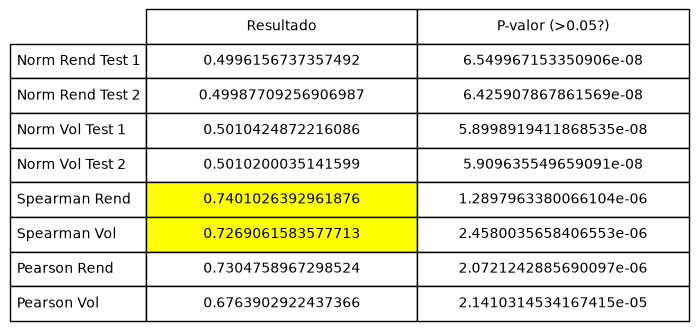

In [130]:
#### Ejecutando pruebas
fecha_test1 = '2018-04-05'

#### Retornos originales
pruebas(rentabilidad_diaria_origin, fecha_test1, dias=30, diff=14) #'2018-04-05'

In [114]:
#### Funcion para extraer estadisticas
def ajustar(data: list):
    ### Buscando el exponente comun
    arr = np.array(data, dtype=float)
    exponentes = np.floor(np.log10(np.abs(arr)))
    exp_comun = int(scipy.stats.mode(exponentes)[0])

    ### Ajustando valores
    resultados = arr/(10**exp_comun)
    resultados = np.round(resultados, 2)
    # resultados = [int(data)] + resultados.tolist()

    return (resultados, exp_comun)

In [135]:
##### Extrayendo informacion
def distribucion(data1: list, data2:list, nom:str, exp_data1:int, exp_data2:int):
    ### Creando histograma
    ANCH = 12
    ALT = 5
    fig, axs = plt.subplots(1,2, figsize=(ANCH, ALT), sharex=False, sharey=False)
    
    ### Histograma 1
    ## Histograma mismo
    min_val = min(data1)
    max_val = max(data1)
    num_centros = int(1 + (np.log(len(data1))/ np.log(2)))
    centros = np.linspace(min_val, max_val, num_centros)
    cuentas, bordes, parches = axs[0].hist(data1, bins=centros, edgecolor='black')

    ## Configuranciones 
    axs[0].set_title(f'Distribución {nom}: Test', fontweight='bold')
    axs[0].set_xlabel(f'Rango de Valores (*e{exp_data1})', fontweight='bold', fontsize=ANCH)
    axs[0].set_ylabel('Frecuencia de Valores en Rango', fontweight='bold', fontsize=ANCH)

    ## Arreglando eje x
    bordes_rangos = [f"{(bordes[i].round(1))}–\n{(bordes[i+1].round(1))}" for i in range(len(bordes)-1)]
    axs[0].set_xticks((bordes[:-1] + bordes[1:])/2)
    axs[0].set_xticklabels(bordes_rangos)

    
    ### Histograma 2
    ## Histograma mismo
    min_val = min(data2)
    max_val = max(data2)
    num_centros = int(1 + (np.log(len(data2))/ np.log(2)))
    centros = np.linspace(min_val, max_val, num_centros)
    cuentas, bordes, parches = axs[1].hist(data2, bins=centros, edgecolor='black')

    ## Configuranciones 
    axs[1].set_title(f'Distribución {nom}: Retest', fontweight='bold')
    axs[1].set_xlabel(f'Rango de Valores (*e{exp_data2})', fontweight='bold', fontsize=ANCH)
    axs[1].set_ylabel('Frecuencia de Valores en Rango', fontweight='bold', fontsize=ANCH)

    
    ## Arreglando eje x
    bordes_rangos = [f"{(bordes[i].round(1))}–\n{(bordes[i+1].round(1))}" for i in range(len(bordes)-1)]
    axs[1].set_xticks((bordes[:-1] + bordes[1:])/2)
    axs[1].set_xticklabels(bordes_rangos)



In [ ]:
#### Prueba de normalidad
def normalidad(data1: list, data2: list, nom:str,exp_data1:int, exp_data2:int):
    #### Haciendo KS prueba
    norm_test1_estad, norm_test1_pvalor = stats.kstest(data1, 'norm')
    norm_test2_estad, norm_test2_pvalor = stats.kstest(data2, 'norm')

    #### Arregalndo formato
    norm_test1_estad = norm_test1_estad.round(3)
    norm_test2_estad = norm_test2_estad.round(3)
    norm_test1_pvalor = format(norm_test1_pvalor, '.3e')
    norm_test2_pvalor = format(norm_test2_pvalor, '.3e')

    #### Tabla de resultados
    ### Data
    data = [
        [32, norm_test1_estad, norm_test1_pvalor],
        [32, norm_test2_estad, norm_test2_pvalor]
    ]

    ### Nombres de columnas y filas
    cols = ['N','Estadístico', 'P-valor']
    rows = [f'{nom}\n- Test',f'{nom}\n- Retest']
    colores = [['white','white', 'yellow']] * 2

    ### Configurando tabla
    ANCH = 7
    ALT = 3
    fig, ax = plt.subplots(figsize=(ANCH,ALT))
    ax.axis('off')

    ## Creando tabla
    tabla = ax.table(
        cellText=data,           # Datos en formato lista o array
        colLabels=cols, # Encabezados de columnas
        colColours=["#dd213a"]*len(cols),
        colWidths=[0.2, 0.2, 0.2],
        rowLabels=rows,    # Encabezados de filas
        rowColours=["#1cb4a8"] * len(rows),
        cellColours=colores,    # Colores
        loc='center',            # Posición de la tabla
        cellLoc='center'         # Alineación del texto en las celdas
    )
    
    ## Aumentando espacio
    for (row, col), cell in tabla.get_celld().items():
        cell.set_height(0.15)  # valor por defecto ~0.1, aumentar para más espacio
        cell.PAD = 0.05        # espacio interno dentro de la celda

    ## Configuraciones de tabla
    ax.set_title(f"Correlación de Spearman- \n{nom}", fontweight="bold", fontsize=14)
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    # tabla.scale(ANCHURA*0.25, ALTURA*0.25)

    plt.show()

In [117]:
#### Correlacion
def correlacion(data1: list, data2: list, nom:str, exp_data1:int, exp_data2:int):
    ### Correlacion Spearman
    ALT = 'two-sided'      #'two-sided', 'less', 'greater'; solo cambia pvalor
    estad, pvalor = stats.spearmanr(data1, data2, alternative=ALT)
    estad = estad.round(3)
    pvalor = format(pvalor,'.3e')

    ### Creado 2 subplots
    ANCH = 12
    ALT = 5
    fig, axs = plt.subplots(1,2, figsize=(ANCH, ALT), sharex=False, sharey=False)
    fig.text(0.5, 0.95, f'{nom}: Spearman Correlación entre Test y Retest', ha='center', fontsize=14, fontweight='bold')

    ### Scatterplot
    axs[0].scatter(data1, data2, color='blue', edgecolors='black', alpha=0.7)
    # axs[0].set_title(f'{nom}: Spearman Correlación entre Test y Retest')
    axs[0].set_xlabel(f'Valores del Test (*e{exp_data1})', fontsize=ANCH)
    axs[0].set_ylabel(f'Valores del Retest (*e{exp_data2})', fontsize=ANCH)

    ### Estadistica
    data = [[32, estad, pvalor]]
    cols = ['N','Estadístico', 'P-valor']
    rows = ['Correlación:\nTest - Retest']
    colores = [['white','yellow', 'white']]
    axs[1].axis('off')
    tabla = axs[1].table(
        cellText=data,           # Datos en formato lista o array
        colLabels=cols, # Encabezados de columnas
        colColours=["#dd213a"]*len(cols),
        colWidths=[0.2, 0.2, 0.2],
        rowLabels=rows,    # Encabezados de filas
        rowColours=["#1cb4a8"] * len(rows),
        cellColours=colores,    # Colores
        loc='center',            # Posición de la tabla
        cellLoc='center'         # Alineación del texto en las celdas
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    tabla.scale(ANCH*0.1, ALT*0.7)

Fechas iniciales: 2018-04-05, 2018-05-16	 Fechas finales: 2018-04-06, 2018-05-17
Fechas iniciales: 2018-04-25, 2018-06-05	 Fechas finales: 2018-04-26, 2018-06-06


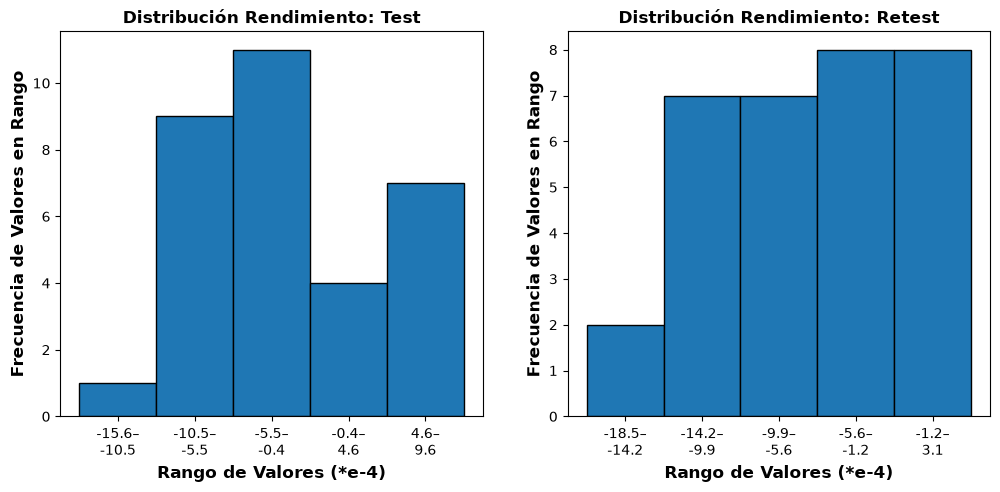

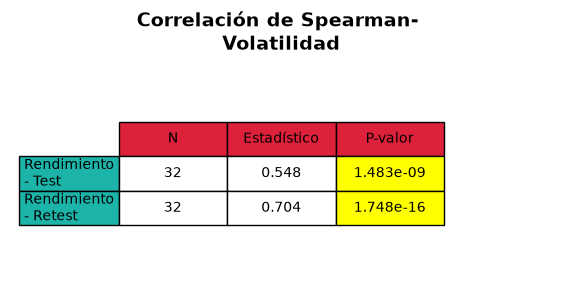

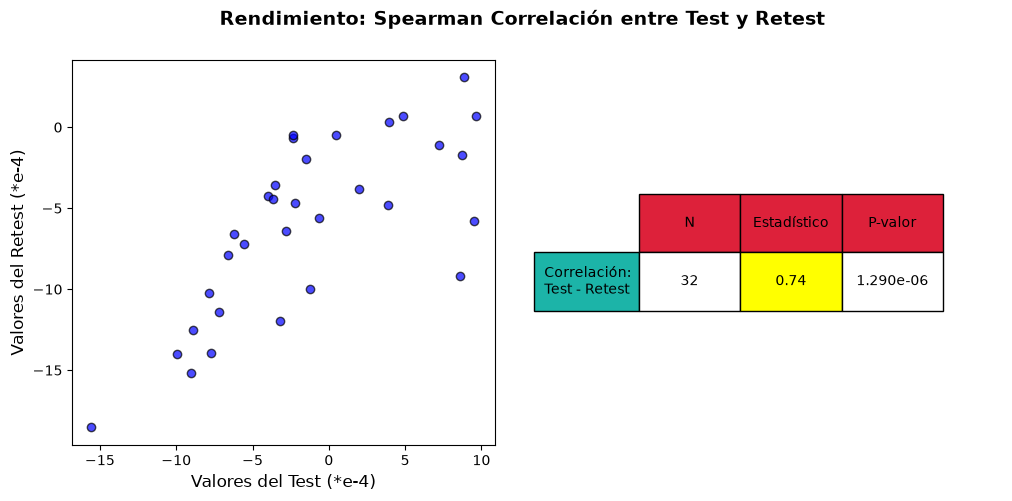

In [137]:
#### Ejecutando pruebas
fecha_test1 = '2018-04-05'
dias = 30
diff = 14

#### Extrayendo datos
indice_rend_test1, indice_std_test1 = test(rentabilidad_diaria_origin, fecha_test1, dias, 0)
indice_rend_test2, indice_std_test2 = test(rentabilidad_diaria_origin, fecha_test1, dias, diff)



#### Ajustado datos
aju_rend_test1, rend_test1_exp = ajustar(indice_rend_test1)
aju_std_test1, std_test1_exp = ajustar(indice_std_test1)
aju_rend_test2, rend_test2_exp = ajustar(indice_rend_test2)
aju_std_test2, std_test2_exp = ajustar(indice_std_test2)


df = pd.DataFrame(aju_rend_test2)
df.to_clipboard(index=False, header=False)


# for i in range(len(indice_rend_test1)):
#     print(f'{indice_std_test1[i]}\t{aju_std_test1[i]}')

##### Distribucion
distribucion(aju_rend_test1, aju_rend_test2, 'Rendimiento', rend_test1_exp, rend_test2_exp)
# distribucion(aju_std_test1, aju_std_test2, 'Volatilidad', std_test1_exp, std_test2_exp)

##### Normalidad
normalidad(aju_rend_test1, aju_rend_test2, 'Rendimiento', rend_test1_exp, rend_test2_exp)
# normalidad(aju_std_test1, aju_std_test2, 'Volatilidad', std_test1_exp, std_test2_exp)

##### Correlacion
correlacion(aju_rend_test1, aju_rend_test2, "Rendimiento", rend_test1_exp, rend_test2_exp)
# correlacion(aju_std_test1, aju_std_test2, 'Volatilidad', std_test1_exp, std_test2_exp)

In [119]:
#### Pretest - Posttest, Cargando datos
df_posttest_crudo = cargar('retornos.csv')
df_pretest_crudo = cargar2('retornos.csv')


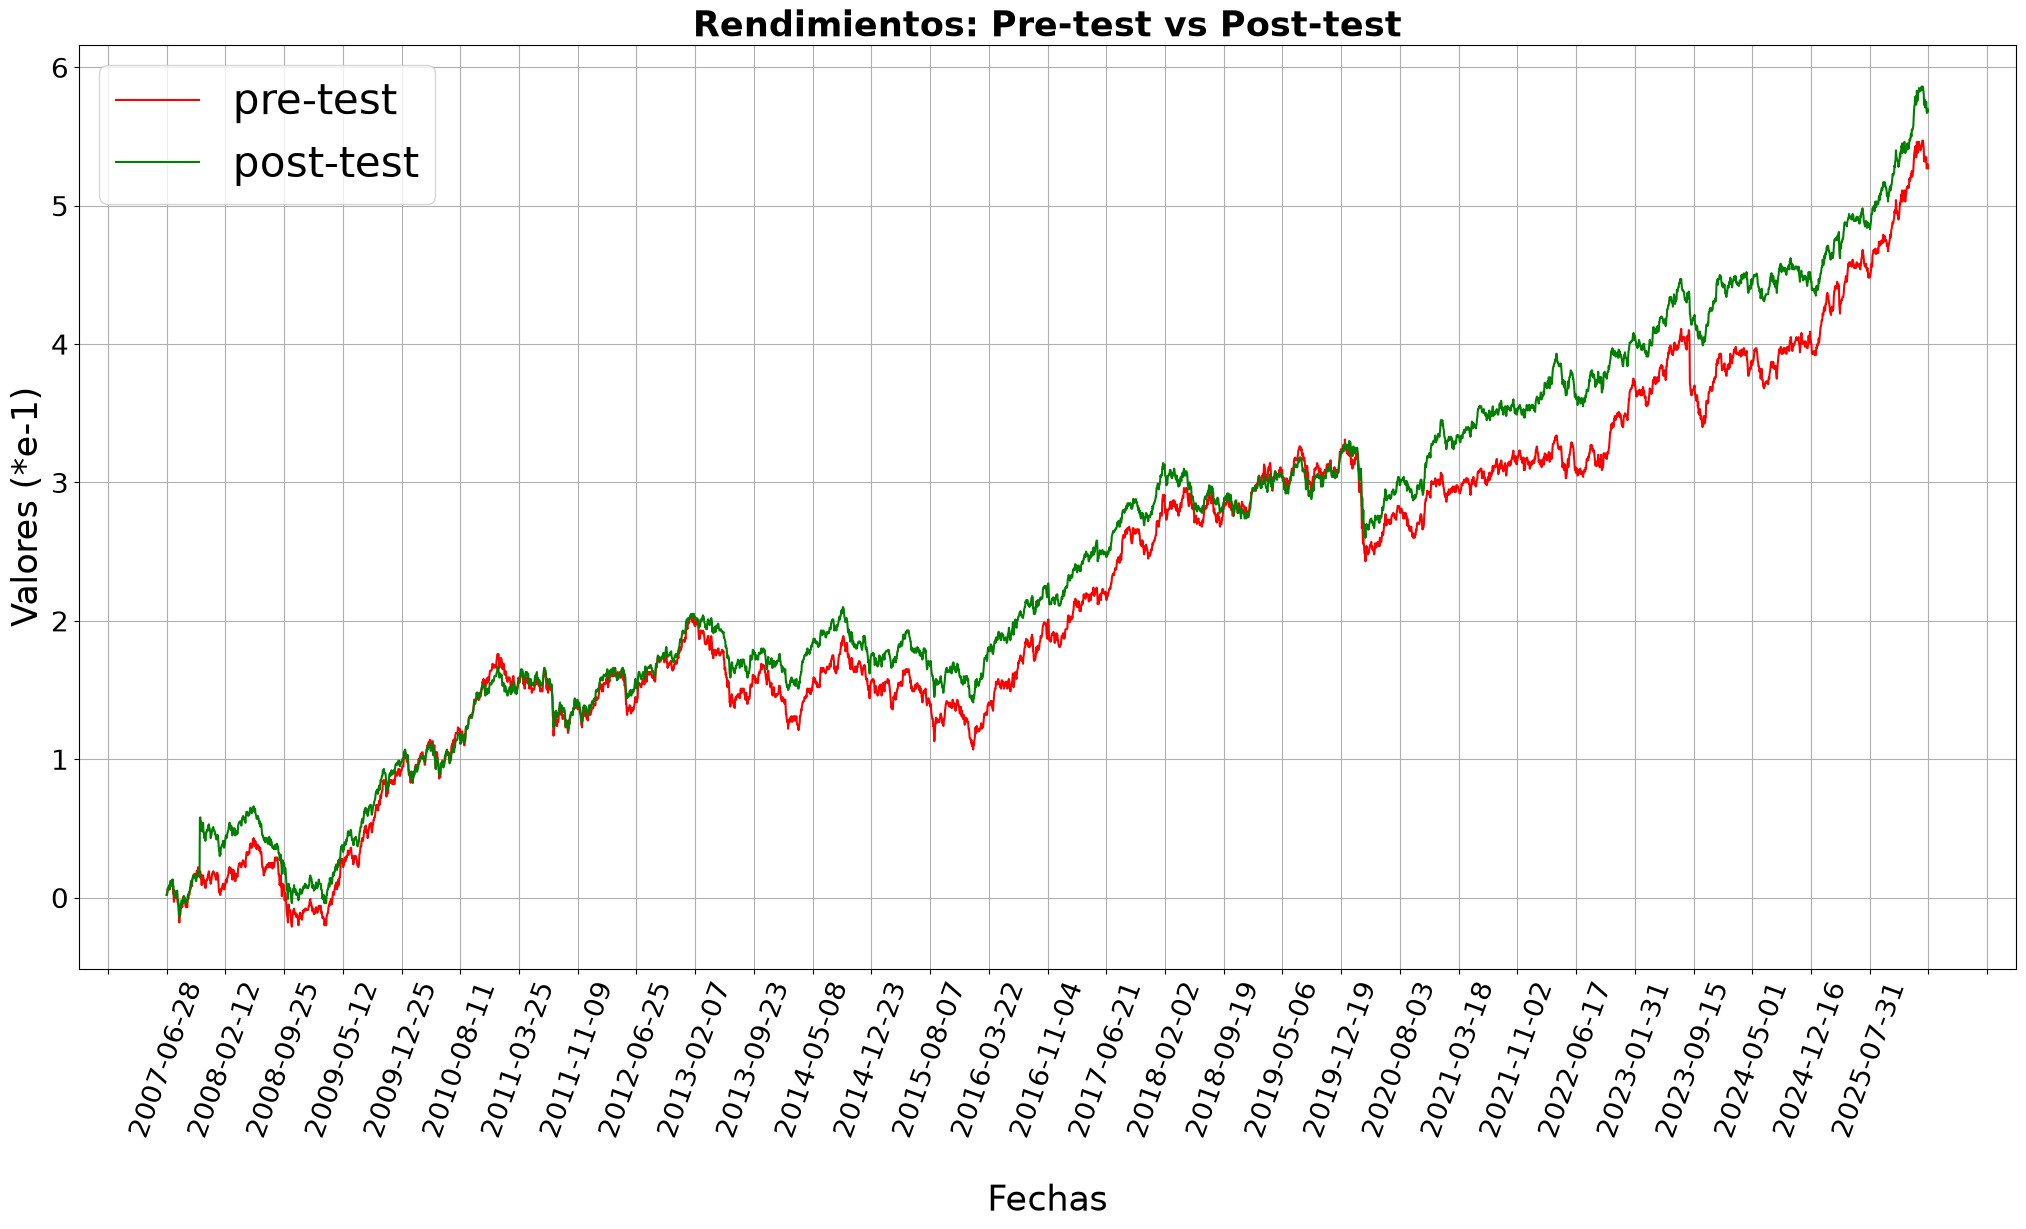

In [120]:
#### Pretest - Posttest: curvas
### Rendimientos acumulados
df_pretest = (1+df_pretest_crudo).cumprod() -1
df_posttest = (1+df_posttest_crudo).cumprod() - 1

### Creando Rendimientos
VENTANA = 500
rend_pretest = df_pretest[:].mean(axis=1)
rend_posttest = df_posttest[:].mean(axis=1)

## Crudos
# rend_pretest = df_pretest_crudo[:].std(axis=1)
# rend_posttest = df_posttest_crudo[:].std(axis=1)


### Ajustando datos
aju_rend_pre, aju_rend_pre_exp = ajustar(rend_pretest.values.tolist())
aju_rend_post, aju_rend_post_exp = ajustar(rend_posttest.values.tolist())

### Creando grafos
from matplotlib.ticker import MultipleLocator
ANCH = 25
ALT = 12
SALTO_X = rend_posttest.shape[0]/30
fig, ax = plt.subplots(figsize=(ANCH,ALT))

## Pretest
ax.plot(
    rend_pretest.index,
    aju_rend_pre,
    color='red',
    label='pre-test',
)

## Posttest
ax.plot(
    rend_posttest.index,
    aju_rend_post,
    color = 'green',
    label = 'post-test'
)

ax.set_title('Rendimientos: Pre-test vs Post-test', fontsize=ANCH, fontweight='bold')
ax.set_ylabel(f'Valores (*e{aju_rend_pre_exp})', fontsize=ANCH)
ax.set_xlabel('Fechas', fontsize=ANCH, labelpad=30)

ax.tick_params(axis='x', labelsize=20, rotation=70) 
ax.tick_params(axis='y', labelsize=20) 
ax.xaxis.set_major_locator(MultipleLocator(SALTO_X))
ax.legend(fontsize=30)
ax.grid(True)

plt.show()
